<a href="https://creativecommons.org">LaserIllumination</a> © 2025 by <a href="https://creativecommons.org">M. Cotelo, A. Lorca (Universidad Politécnica de Madrid)</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/sa.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">

# LaserIllumination

Authors:
- Manuel Cotelo Ferreiro (<manuel.cotelo@upm.es>) (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid)
- Alberto Lorca (<alberto.lorca@alumnos.upm.es>) (Universidad Politécnica de Madrid)

In [25]:
import os
import sys
import argparse
import string

In [26]:
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
#!pip install scipy

## Helper functions

In [27]:
def sph_to_cart(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])

## Define and create ports based on NIF

In [28]:
def create_ports(theta, num, long_ref, root, color, energy, wavelength):
    list_long = long_ref + np.linspace(0., 2.*np.pi, num, endpoint=False)
    return [{
        'name': f'{root}J{i+1}',
        'LAT': np.pi/2. - theta,
        'LONG': long,
        'color': color,
        'foco': None,              # <-- Se asignará después según el anillo
        'energia': energy,
        'longonda': wavelength,
    } for (i, long) in enumerate(list_long)]


In [29]:
ports = []
ports += create_ports(np.deg2rad(23.5), 4, 0.,        'NP1', color='red',    energy=1.0, wavelength=351e-6)
ports += create_ports(np.deg2rad(30.0), 4, np.pi/4.,  'NP2', color='blue',   energy=1.0, wavelength=351e-6)
ports += create_ports(np.deg2rad(44.5), 8, np.pi/16., 'NP3', color='green',  energy=1.0, wavelength=351e-6)
ports += create_ports(np.deg2rad(50.0), 8, 3*np.pi/16., 'NP4', color='purple', energy=1.0, wavelength=351e-6)

ports += create_ports(np.pi - np.deg2rad(23.5), 4, 0.,        'SP1', color='red',    energy=1.0, wavelength=351e-6)
ports += create_ports(np.pi - np.deg2rad(30.0), 4, np.pi/4.,  'SP2', color='blue',   energy=1.0, wavelength=351e-6)
ports += create_ports(np.pi - np.deg2rad(44.5), 8, np.pi/16., 'SP3', color='green',  energy=1.0, wavelength=351e-6)
ports += create_ports(np.pi - np.deg2rad(50.0), 8, 3*np.pi/16., 'SP4', color='purple', energy=1.0, wavelength=351e-6)

ports = pd.DataFrame(ports)


## Focal distance

In [30]:
focal_map = {
    "NP1": 8.0,  "SP1": 8.0,
    "NP2": 8.8,  "SP2": 8.8,
    "NP3": 10.0, "SP3": 10.0,
    "NP4": 12.0, "SP4": 12.0,
}

def compute_focus(normal, f_distance):
    # El foco está f metros hacia dentro del blanco
    return -normal * f_distance

def assign_real_focus(row):
    ring = row["name"][:3]
    f_dist = focal_map[ring]
    return compute_focus(row["normal"], f_dist)


## Define and create windows based on NIF

In [31]:
def compute_tangents_and_subwindows(row):
	# Vector normal a la esfera en esa LAT y LONG
	normal = sph_to_cart(1.0, np.pi/2. - row['LAT'], row['LONG'])
	normal = normal / np.linalg.norm(normal)

	# Vectores tangentes (t1, t2)
	arbitrary = np.array([1, 0, 0]) if abs(normal[0]) < 0.9 else np.array([0, 1, 0])
	# Se elige un vector arbitrario que no sea paralelo al normal (para evitar producir un vector cero al hacer el producto cruz).
	t1 = np.cross(normal, arbitrary)
	t1 /= np.linalg.norm(t1)
	t2 = np.cross(normal, t1)
	t2 /= np.linalg.norm(t2)

	# Dimensiones de la ventana principal y subventanas
	ports_size = 0.80 # 80 cm en metros
	lx = ly = ports_size / 2.0 # 40 cm

	offsets = [
		(+lx/2, +ly/2),
		(-lx/2, +ly/2),
		(+lx/2, -ly/2),
		(-lx/2, -ly/2)
	]

	centers = [normal + dx * t1 + dy * t2 for dx, dy in offsets]

	return pd.Series({
		'normal': normal,
		't1': t1,
		't2': t2,
		'lx': lx,
		'ly': ly,
		'windows': centers
	})

# 1. Primero calcular normales, t1, t2, ventanas
ports[["normal", "t1", "t2", "lx", "ly", "windows"]] = ports.apply(compute_tangents_and_subwindows, axis=1)

# 2. Después asignar el foco real (porque ya existe 'normal')
ports["foco"] = ports.apply(assign_real_focus, axis=1)


# El DataFrame 'ports' ahora tiene columnas adicionales con los vectores normales, tangentes y centros de subventanas
ports.head()




,name,LAT,LONG,color,foco,energia,longonda,normal,t1,t2,lx,ly,windows
0,NP1J1,1.160644,0.000000,red,"[-3.1899925514019696, -0.0, -7.336480595080992]",1.0,0.000351,"[0.3987490689252462, 0.0, 0.917060074385124]","[0.0, 1.0, 0.0]","[-0.917060074385124, 0.0, 0.3987490689252462]",0.4,0.4,"[[0.21533705404822137, 0.2, 0.9968098881701732..."
1,NP1J2,1.160644,1.570796,red,"[-1.9533070836891602e-16, -3.1899925514019696,...",1.0,0.000351,"[2.4416338546114503e-17, 0.3987490689252462, 0...","[0.0, 0.917060074385124, -0.3987490689252462]","[-1.0, 9.735992261826758e-18, 2.23912492433121...",0.4,0.4,"[[-0.19999999999999998, 0.582161083802271, 0.8..."
2,NP1J3,1.160644,3.141593,red,"[3.1899925514019696, -3.9066141673783204e-16, ...",1.0,0.000351,"[-0.3987490689252462, 4.8832677092229005e-17, ...","[0.0, 1.0, -5.32491583225566e-17]","[-0.917060074385124, -2.1233052302172467e-17, ...",0.4,0.4,"[[-0.582161083802271, 0.20000000000000007, 0.8..."
3,NP1J4,1.160644,4.712389,red,"[5.859921251067481e-16, 3.1899925514019696, -7...",1.0,0.000351,"[-7.324901563834351e-17, -0.3987490689252462, ...","[-0.0, 0.917060074385124, 0.3987490689252462]","[-1.0, 2.920797678548027e-17, -6.7173747729936...",0.4,0.4,"[[-0.2000000000000001, -0.21533705404822137, 0..."
4,NP2J1,1.047198,0.785398,blue,"[-3.1112698372208087, -3.1112698372208087, -7....",1.0,0.000351,"[0.3535533905932737, 0.3535533905932737, 0.866...","[0.0, 0.9258200997725515, -0.37796447300922714]","[-0.9354143466934854, 0.13363062095621214, 0.3...",0.4,0.4,"[[0.16647052125457656, 0.5654435347390264, 0.8..."


## Create disposition of ports in NIF in 2D

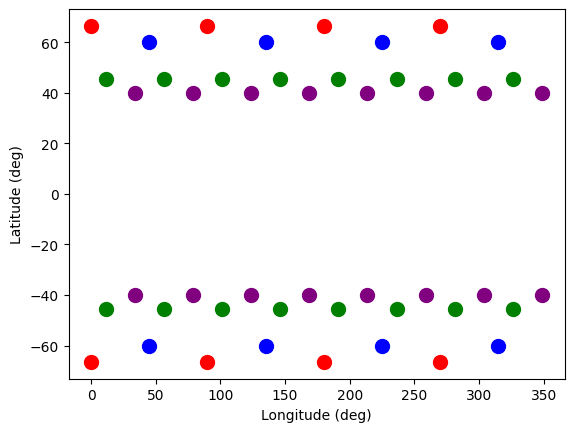

In [32]:
fig, ax = plt.subplots( 1, 1, )

ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
for ci in ports['color'].unique():
    subdf = ports[ ports['color'] == ci ]
    ax.scatter( np.rad2deg(subdf['LONG']), np.rad2deg(subdf['LAT']), s=100, c=ci, marker='o', label=f'Laser Ports {ci}', zorder=10, )

## Create radial disposition of ports in 2D

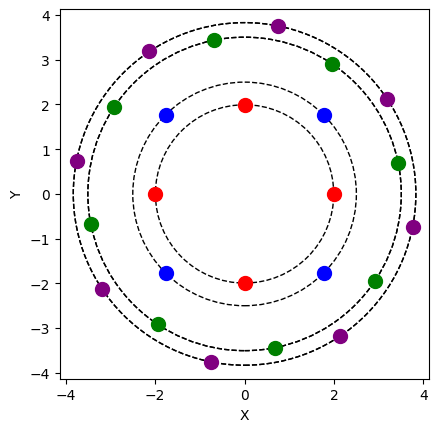

In [33]:
fig, ax = plt.subplots( 1, 1, )

ports_north = ports[ports['LAT'] > 0. ]

pos = sph_to_cart( 5, np.pi/2. - ports_north['LAT'], ports_north['LONG'] )
ds = np.sqrt(pos[0,:]**2 + pos[1,:]**2)
ls = np.unique(ds)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal', 'box')

for ci in ports_north['color'].unique():
    subdf = ports_north[ ports_north['color'] == ci ]
    ax.scatter( pos[0,subdf.index], pos[1,subdf.index], s=100, c=ci, marker='o', label=f'Laser Ports {ci}', zorder=10, )

for li in ls:
  circle = plt.Circle( (0.,0.), li, color='black', fill=False, linestyle='--', zorder=1, )
  ax.add_artist(circle)


## Create 3D disposition of ports

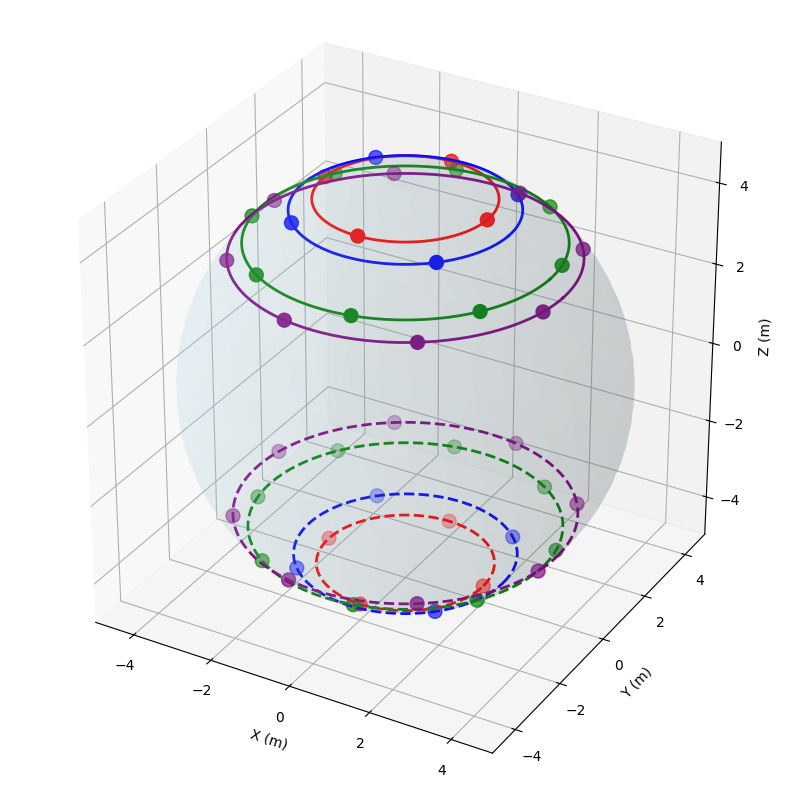

In [34]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(10,10))

ax.set_box_aspect([1,1,1])

# Límites espaciales según el radio real de la cámara
R = 5   # radio real de la cámara en metros
ax.set_xlim([-R, R])
ax.set_ylim([-R, R])
ax.set_zlim([-R, R])

# --- Dibujar los puertos ---
for ci in ports['color'].unique():
    subdf = ports[ports['color'] == ci]
    
    # Conversión esférica → cartesiana con radio real
    pos = sph_to_cart(R, np.pi/2. - subdf['LAT'], subdf['LONG'])
    
    ax.scatter(pos[0,:], pos[1,:], pos[2,:], 
               s=100, c=ci, marker='o',
               label=f'Laser Ports {ci}', zorder=10)

# --- Dibujar anillos como círculos perfectos ---
for ci in ports['color'].unique():
    for hemisphere, subdf in [
        ("north", ports[(ports['color'] == ci) & (ports['LAT'] > 0)]),
        ("south", ports[(ports['color'] == ci) & (ports['LAT'] < 0)])
    ]:
        if not subdf.empty:
            # Ángulo polar promedio del anillo
            theta0 = np.mean(np.pi/2. - subdf['LAT'].values)

            # Círculo completo en ese theta, escalado al radio real
            phi = np.linspace(0, 2*np.pi, 200)
            x = R * np.sin(theta0) * np.cos(phi)
            y = R * np.sin(theta0) * np.sin(phi)
            z = R * np.cos(theta0) * np.ones_like(phi)

            ax.plot(x, y, z, color=ci,
                    linewidth=2,
                    linestyle="-" if hemisphere=="north" else "--",
                    zorder=5)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# --- Esfera (cámara) ---
u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 40)
x_sphere = R * np.outer(np.cos(u), np.sin(v))
y_sphere = R * np.outer(np.sin(u), np.sin(v))
z_sphere = R * np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(x_sphere, y_sphere, z_sphere, 
                alpha=0.12, linewidth=0, color='lightblue')

plt.show()


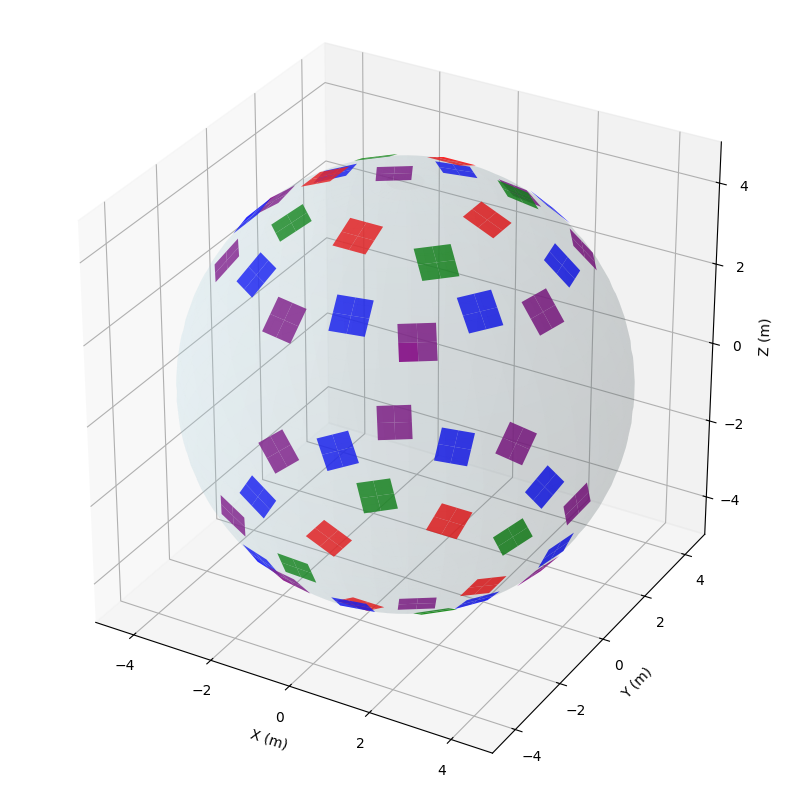

In [41]:
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Radio real de la cámara ---
R = 5.0

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# --- Dibujar esfera ---
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, np.pi, 40)
x = R * np.outer(np.cos(u), np.sin(v))
y = R * np.outer(np.sin(u), np.sin(v))
z = R * np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x, y, z, color='lightblue', alpha=0.12, linewidth=0)

# --- Colores por anillo ---
ring_colors = {
    "NP1": "red", "SP1": "red",
    "NP2": "green", "SP2": "green",
    "NP3": "blue", "SP3": "blue",
    "NP4": "purple", "SP4": "purple",
}

# --- Dibujar subventanas ---
for idx, row in ports.iterrows():

    # Identificar anillo
    port_name = row["name"]
    ring_id = port_name[:3]
    color = ring_colors.get(ring_id, "orange")

    # Coordenadas esféricas
    theta = np.pi/2 - row["LAT"]
    phi = row["LONG"]

    # Normal radial
    normal = np.array([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)
    ])

    # --- Vectores alineados con meridianos/paralelos ---
    # Tangente azimutal (este-oeste)
    t1 = np.array([-np.sin(phi), np.cos(phi), 0.0])
    t1 /= np.linalg.norm(t1)

    # Tangente polar (norte-sur)
    t2 = np.cross(normal, t1)
    t2 /= np.linalg.norm(t2)

    # Tamaños reales
    lx = row["lx"]
    ly = row["ly"]

    # Centro de la ventana
    center = normal * R

    # Offsets de las 4 subventanas
    offsets = [
        (+lx/2, +ly/2),
        (-lx/2, +ly/2),
        (+lx/2, -ly/2),
        (-lx/2, -ly/2)
    ]

    # Dibujar cada subventana
    for dx, dy in offsets:

        sub_center = center + dx * t1 + dy * t2

        half_x = lx / 2
        half_y = ly / 2

        p1 = sub_center + half_x * t1 + half_y * t2
        p2 = sub_center - half_x * t1 + half_y * t2
        p3 = sub_center - half_x * t1 - half_y * t2
        p4 = sub_center + half_x * t1 - half_y * t2

        verts = [ [p1, p2, p3, p4] ]
        poly = Poly3DCollection(verts, alpha=0.85, facecolor=color)
        ax.add_collection3d(poly)

# --- Ajustes de la figura ---
ax.set_xlim([-R, R])
ax.set_ylim([-R, R])
ax.set_zlim([-R, R])
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_box_aspect([1,1,1])

plt.show()


## Create 3D simulation of beams in the ports

In [42]:

# --- Radio de la esfera ---
sphere_radius = 5
sphere = pv.Sphere(radius=sphere_radius, theta_resolution=60, phi_resolution=60)

# --- Inicializar plotter ---
plotter = pv.Plotter()
plotter.add_mesh(sphere, color="lightblue", opacity=0.1)

# --- Colores por anillos ---
ring_colors = {
    "NP1": "red", "SP1": "red",
    "NP2": "green", "SP2": "green",
    "NP3": "blue", "SP3": "blue",
    "NP4": "purple", "SP4": "purple",
}

# --- Recorrer cada puerto ---
for idx, row in ports.iterrows():

    # Nombre del puerto (ej. NP1J1)
    port_name = row["name"]
    ring_id = port_name[:3]
    color = ring_colors.get(ring_id, "orange")

    # Coordenadas esféricas del puerto
    theta = np.pi/2 - row["LAT"]
    phi = row["LONG"]

    # --- Normal radial ---
    normal = np.array([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)
    ])

    # --- Vectores alineados con meridianos/paralelos ---
    # Tangente azimutal (este-oeste)
    t1 = np.array([-np.sin(phi), np.cos(phi), 0.0])
    t1 /= np.linalg.norm(t1)

    # Tangente polar (norte-sur)
    t2 = np.cross(normal, t1)
    t2 /= np.linalg.norm(t2)

    # Tamaños reales de la ventana
    lx = row["lx"]
    ly = row["ly"]

    # Centro de la ventana principal
    port_center = normal * sphere_radius

    # Foco real del haz
    focus_point = row["foco"]

    # Offsets de las 4 subventanas
    offsets = [
        (+lx/2, +ly/2),
        (-lx/2, +ly/2),
        (+lx/2, -ly/2),
        (-lx/2, -ly/2)
    ]

    # --- Dibujar cada subventana y su pirámide ---
    for dx, dy in offsets:

        # Centro de la subventana
        sub_center = port_center + dx * t1 + dy * t2

        half_x = lx / 2
        half_y = ly / 2

        # Esquinas del rectángulo
        p1 = sub_center + half_x * t1 + half_y * t2
        p2 = sub_center - half_x * t1 + half_y * t2
        p3 = sub_center - half_x * t1 - half_y * t2
        p4 = sub_center + half_x * t1 - half_y * t2

        # Pirámide con base p1-p2-p3-p4 y vértice en el foco
        pyramid = pv.Pyramid([p1, p2, p3, p4, focus_point])
        plotter.add_mesh(pyramid, color=color, opacity=0.3, show_edges=True)

plotter.show()


Widget(value='<iframe src="http://localhost:63403/index.html?ui=P_0x1bb97a2f390_13&reconnect=auto" class="pyvi…